## Vorticity over the Andes

This example demonstrates visualising a highly noisy field with smooth contours.

ecmwf-vorticity.grib:   0%|          | 0.00/4.09M [00:00<?, ?B/s]

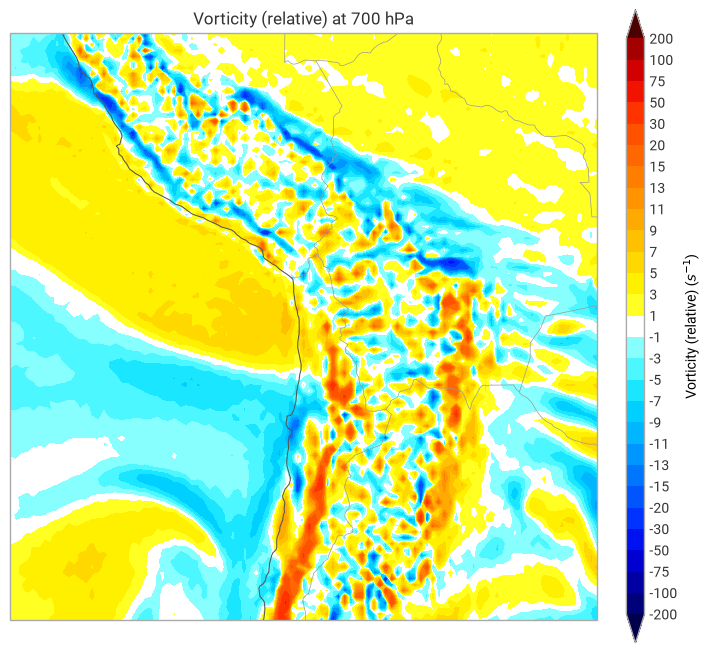

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

PRESSURE = 700

LEVELS = [
    1.0,
    3.0,
    5.0,
    7.0,
    9.0,
    11.0,
    13.0,
    15.0,
    20.0,
    30.0,
    50.0,
    75.0,
    100.0,
    200.0,
]
LEVELS = [0 - level for level in LEVELS[::-1]] + LEVELS

COLORS = [
    "#00004d",
    "#000080",
    "#0000b3",
    "#0000e6",
    "#0026ff",
    "#004dff",
    "#0073ff",
    "#0099ff",
    "#00bfff",
    "#00d9ff",
    "#33f2ff",
    "#73ffff",
    "#bfffff",
    "white",
    "#ffff00",
    "#ffea00",
    "#ffcc00",
    "#ffb300",
    "#ff9900",
    "#ff8000",
    "#ff6600",
    "#ff4d00",
    "#ff2600",
    "#e60000",
    "#b30000",
    "#800000",
    "#4d0000",
]

STYLE = ekp.styles.Contour(
    colors=COLORS,
    levels=LEVELS,
    extend="both",
    scale_factor=10**5,
    ticks=LEVELS,
)

vorticity = ekd.from_source("sample", "ecmwf-vorticity.grib").to_fieldlist()

chart = ekp.Map(domain=[-80, -60, -30, -10])

chart.contourf(vorticity.sel({"vertical.level": PRESSURE}), style=STYLE)

chart.title("{variable_name} at {level} hPa")
chart.legend(location="right")

chart.borders()
chart.coastlines()

chart.show()